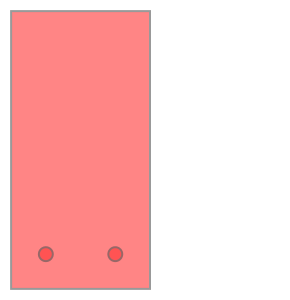

In [1]:
from shapely import Polygon

from structuralcodes import set_design_code
from structuralcodes.geometry import SurfaceGeometry, add_reinforcement
from structuralcodes.materials.concrete import create_concrete
from structuralcodes.materials.reinforcement import create_reinforcement
from structuralcodes.sections import GenericSection

# Set the active design code
set_design_code('ec2_2004')
# Create a concrete and a reinforcement
fck = 45
fyk = 500
ftk = 550
Es = 200000
epsuk = 0.07

# These factory functions create concrete and reinforcement materials according
# to the globally set design code
concrete = create_concrete(fck=fck)
reinforcement = create_reinforcement(fyk=fyk, Es=Es, ftk=ftk, epsuk=epsuk)


# Create a rectangular geometry
width = 250
height = 500
polygon = Polygon(
    [
        (-width / 2, -height / 2),
        (width / 2, -height / 2),
        (width / 2, height / 2),
        (-width / 2, height / 2),
    ]
)  # We leverage shapely to create geometries
geometry = SurfaceGeometry(
    poly=polygon, material=concrete, group_label='concrete'
)  # A SurfaceGeometry is a shapely Polygon with an assigned material


# Add reinforcement
diameter_reinf = 25
cover = 50

geometry = add_reinforcement(
    geometry,
    (
        -width / 2 + cover + diameter_reinf / 2,
        -height / 2 + cover + diameter_reinf / 2,
    ),
    diameter_reinf,
    reinforcement,
    group_label='bar 1',
)  # The add_reinforcement function returns a CompoundGeometry
geometry = add_reinforcement(
    geometry,
    (
        width / 2 - cover - diameter_reinf / 2,
        -height / 2 + cover + diameter_reinf / 2,
    ),
    diameter_reinf,
    reinforcement,
    group_label='bar 2',
)

# Create section
section = GenericSection(geometry)
section.geometry

In [8]:
strain = section.section_calculator.calculate_strain_profile(
    n=-200.0 * 1e3,
    my=-200.0 * 1e6,
    mz=0.0 * 1e6,
)

print(strain)


[0.0006834805501966458, -7.940223889374192e-06, 1.6393023053829137e-21]


In [9]:
results = section.section_calculator.get_stress_point(
    y=width / 2 - cover - diameter_reinf / 2,
    z=-height / 2 + cover + diameter_reinf / 2,
    eps_a=strain[0],
    chi_y=strain[1],
    chi_z=strain[2],
    where=0,
)

if results:
    for result in results:
        print(f'Stres in ({result.y}, {result.z}): {result.stress}')
        print(f'Strain: {result.strain}')
        print(f'Geometry: {result.geometry_group_label}')
        print('---')
else:
    print('Point outside any geometry')

Stres in (62.5, -187.5): 434.4545058908614
Strain: 0.002172272529454307
Geometry: bar 2
---
Stres in (62.5, -187.5): 0
Strain: 0.002172272529454307
Geometry: concrete
---


In [10]:
results = section.section_calculator.get_stress_point(
    y=0,
    z=height / 2,
    eps_a=strain[0],
    chi_y=strain[1],
    chi_z=strain[2],
    where=0,
)

if results:
    for result in results:
        print(f'Stres in ({result.y}, {result.z}): {result.stress}')
        print(f'Strain: {result.strain}')
        print(f'Geometry: {result.geometry_group_label}')
        print('---')
else:
    print('Point outside any geometry')

Stres in (0, 250.0): -26.341523317880416
Strain: -0.0013015754221469022
Geometry: concrete
---
